In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Читаем данные 
Датасеты для оценки результатов AB теста получены генератором датасетов https://www.ab-tests.ru/<br>
transactions.csv - действия пользователя (допустим, что это факт покупки с выручкой в поле amount)<br>
users.csv - справочник пользователей тестовой и контрольной групп



## transactions.csv

In [2]:
df_tr = pd.read_csv('transactions.csv')
df_tr.head()

,id,amount,date
0,00016e1c9af64b700a810ae53e4fe832,3830.0,2024-04-18
1,00084bf68a80ef04a7a03b331c17f160,2911.0,2024-04-17
2,00140d5c2f9ba5fe90648194448a859b,4658.0,2024-04-17
3,00158e301d4164b2cce0fbc7dbb620fc,4399.0,2024-04-20
4,00172c96ea53fc47ef0ee85df0c756b2,2110.0,2024-04-18


In [3]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19639 entries, 0 to 19638
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      19639 non-null  object 
 1   amount  19639 non-null  float64
 2   date    19639 non-null  object 
dtypes: float64(1), object(2)
memory usage: 460.4+ KB


In [4]:
#приводим дату к нужному формату
df_tr['date'] = pd.to_datetime(df_tr['date'],format='%Y.%m.%d')

In [5]:
print(f'Дубликатов {df_tr.duplicated().sum()}')
print(f'Пустых значений {df_tr.isna().sum().sum()}')



Дубликатов 0
Пустых значений 0


## users.csv

In [6]:
df_users = pd.read_csv('users.csv')
df_users.head()

,id,group
0,e4943f7efd3e4390ff2dc944ebd28f59,control
1,0e1ed47cf4c0983d09dbcedab1f6e2e2,control
2,2ac26e03e5626d57b2b39292796c23a8,control
3,d6bc45071f311fa56fd75cb60fa2c040,control
4,3308a2d75b787543806308f51e37ed29,control


In [7]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81240 entries, 0 to 81239
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      81240 non-null  object
 1   group   81240 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [8]:
print(f'Дубликатов {df_users.duplicated().sum()}')
print(f'Пустых значений {df_users.isna().sum().sum()}')


Дубликатов 0
Пустых значений 0


Проверим, что каждый пользователь попадает только в одну группу 

In [9]:
cnt = df_users.shape[0]
users=df_users['id'].nunique()
print(f'Строк в датасете {cnt}')
print(f'Уникальных юзеров {users}')

Строк в датасете 81240
Уникальных юзеров 81240


## Получаем два датасета: контрольный и тестовый 

In [10]:
df_control = pd.merge(df_users.query('group=="control"'),df_tr,on ='id', how = 'inner')
df_test = pd.merge(df_users.query('group=="treatment"'),df_tr,on ='id', how = 'inner')

In [11]:
print(f'строк в контрольной группе {df_control.shape[0]}')
print(f'строк в тестовой группе {df_test.shape[0]}')

строк в контрольной группе 9016
строк в тестовой группе 10623


# Исследовательский анализ данных

Проверим средние значения выборок

In [12]:
avg_control_amount = df_control.amount.mean()
avg_test_amount = df_test.amount.mean()
total_control_amount = df_control.amount.sum()
total_test_amount = df_test.amount.sum()
x_amount = ['control_amount', 'test_amount']
y_amount = [avg_control_amount, avg_test_amount]

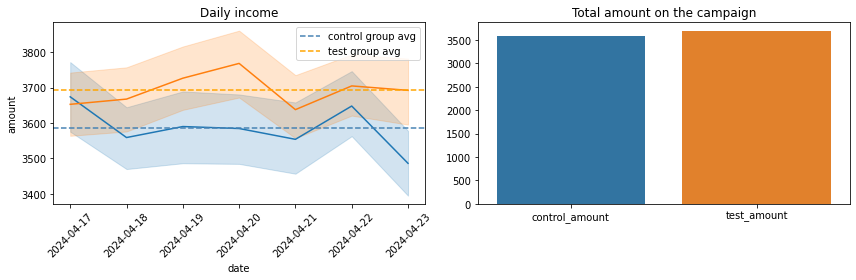

In [13]:
fig, ax = plt.subplots(nrows = 1,ncols=2, figsize=(12,4))
ax[0] = sns.lineplot(data=df_control, x='date', y='amount', ax=ax[0])
ax[0].tick_params('x', labelrotation=45)
ax[0].axhline(y=avg_control_amount, color='steelblue', ls='--', label='control group avg')
ax[0].set_title('Daily income')
ax[0] = sns.lineplot(data=df_test, x='date', y='amount', ax=ax[0])
ax[0].axhline(y=avg_test_amount, color='orange', ls='--', label='test group avg')
ax[0].legend(loc='upper right')

ax[1] = sns.barplot(x=x_amount, y=y_amount)
ax[1].set_title('Total amount on the campaign')
plt.tight_layout()


                    

Средняя сумма покупок в тестовой группе на 3% выше, чем в контрольной, также на графике слева заметно, что динамика роста и падения показателя в двух группах не сильно отличается.<br> Проверим распредление данных в выборках: 

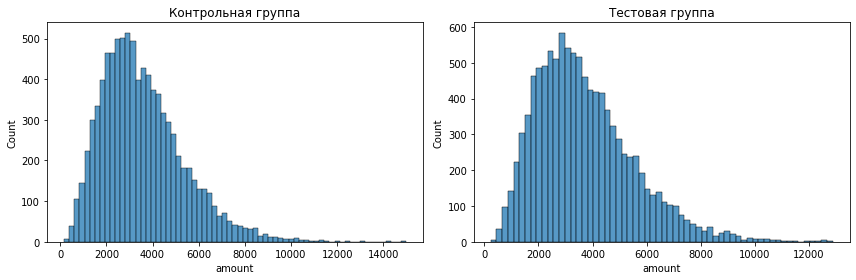

In [14]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(12,4))
ax[0] = sns.histplot(x=df_control['amount'],ax=ax[0])
ax[0].set_title('Контрольная группа')
ax[1] = sns.histplot(x=df_test['amount'],ax=ax[1])
ax[1].set_title('Тестовая группа')
plt.tight_layout()

Данные скошены вправо (так часто распределена выручка)

## Выбросы
Проверим данные на наличие выбросов


Text(0.5, 1.0, 'Test group')

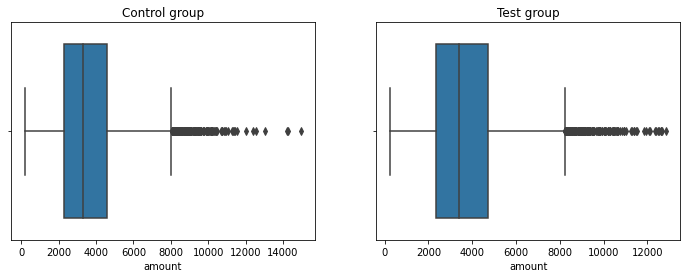

In [15]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize = (12,4))
ax[0]=sns.boxplot(x=df_control.amount,ax=ax[0])
ax[0].set_title('Control group')
ax[1]=sns.boxplot(x=df_test.amount,ax=ax[1])
ax[1].set_title('Test group')

Выбросы есть в обеих выборках, оценим их процент:

In [16]:
def get_outliers_percentage(data):        
    q1=data['amount'].quantile(0.25)
    q3=data['amount'].quantile(0.75)
    iqr = q3-q1
    df_outrange = data.query('amount >= @q3+1.5*@iqr or amount <= @q1-1.5*@iqr')
    result = df_outrange.shape[0]/data.shape[0]
    return result
   
print(f'Контрольная группа за пределами {get_outliers_percentage(df_control):%}')
print(f'Тестовая группа за пределами {get_outliers_percentage(df_test):%}')


Контрольная группа за пределами 2.140639%
Тестовая группа за пределами 2.052151%


Процент выбросов в тестовой и контрольной группах относительно небольшой, можно выбросы удалить.



In [17]:
def remove_outliers_iqr(data):
    q1=data['amount'].quantile(0.25)
    q3=data['amount'].quantile(0.75)
    iqr = q3-q1    
    df_inrange = data.query('amount < @q3+1.5*@iqr and amount > @q1-1.5*@iqr')    
    return df_inrange

df_control_capped=remove_outliers_iqr(df_control)
df_test_capped=remove_outliers_iqr(df_test)


Проверим распределение после удаления выбросов

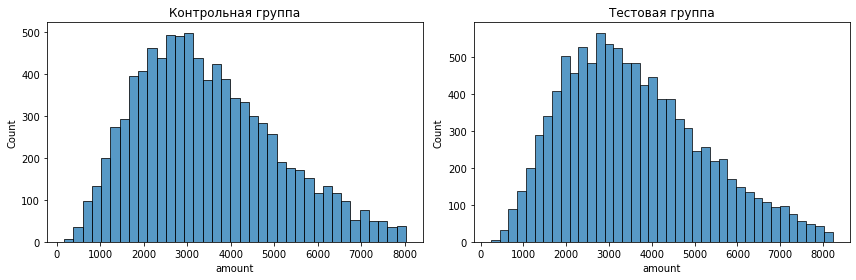

In [18]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(12,4))
ax[0] = sns.histplot(x=df_control_capped['amount'],ax=ax[0])
ax[0].set_title('Контрольная группа')
ax[1] = sns.histplot(x=df_test_capped['amount'],ax=ax[1])
ax[1].set_title('Тестовая группа')
plt.tight_layout()

Данные все еще скошены вправо <BR>Распределение приблизилось к нормальныму

# Тестирование

## A/A тест 

проверим правильность разбиения пользователей на группы таким способом: <br>
разобьем контрольную  группу на две <br> и проведем ttest и Mann-Whitney тест для этих групп 1000 раз

In [19]:
def run_aa_test(data, n_iterations=1000, test_type='ttest'):
    """
    Многократный A/A-тест на одних и тех же данных
    
    test_type: 'ttest' для t-теста, 'mw' для Mann-Whitney
    """
    p_values = []
    
    for i in range(n_iterations):
        # Разбиваем контрольную группу на две случайные
        shuffled = data.copy()
        np.random.shuffle(shuffled)
        n1 = len(shuffled) // 2
        group_a = shuffled[:n1]
        group_b = shuffled[n1:]
        
        # Применяем статтест
        if test_type == 'ttest':
            _, p_val = stats.ttest_ind(group_b, group_a, equal_var=False)
        else:  # Mann-Whitney
            _, p_val = stats.mannwhitneyu(group_b, group_a)
        
        p_values.append(p_val)
    
    return np.array(p_values)

# Запускаем 1000 A/A тестов
print("\nЗапуск 1000 A/A-тестов... ")
p_values_ttest = run_aa_test(df_control_capped['amount'].to_list(), n_iterations=1000, test_type='ttest')
p_values_mw = run_aa_test(df_control_capped['amount'].to_list(), n_iterations=1000, test_type='mw')

# ==================================================
# 5. Анализ результатов
# ==================================================
false_positives_ttest = np.mean(p_values_ttest < 0.05)
false_positives_mw = np.mean(p_values_mw < 0.05)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ 1000 A/A-ТЕСТОВ")
print("="*50)
print(f"\nt-test:")
print(f"  Доля ложноположительных (p < 0.05): {false_positives_ttest*100:.2f}%")
print(f"  Ожидаемое значение: 5%")
print(f"  Медиана p-value: {np.median(p_values_ttest):.4f}")

print(f"\nMann-Whitney:")
print(f"  Доля ложноположительных (p < 0.05): {false_positives_mw*100:.2f}%")
print(f"  Ожидаемое значение: 5%")
print(f"  Медиана p-value: {np.median(p_values_mw):.4f}")

# Оценка качества
if 0.03 < false_positives_ttest < 0.08:
    print("\n A/A-тест пройден: уровень ложных срабатываний близок к 5%")
else:
    print("\n A/A-тест НЕ ПРОЙДЕН: есть проблемы с рандомизацией или статтестом")




Запуск 1000 A/A-тестов... 

РЕЗУЛЬТАТЫ 1000 A/A-ТЕСТОВ

t-test:
  Доля ложноположительных (p < 0.05): 5.10%
  Ожидаемое значение: 5%
  Медиана p-value: 0.5162

Mann-Whitney:
  Доля ложноположительных (p < 0.05): 10.10%
  Ожидаемое значение: 5%
  Медиана p-value: 0.2435

 A/A-тест пройден: уровень ложных срабатываний близок к 5%


Mann-Whitney показал повышенный уровень ложных срабатываний (8.3%), что может указывать на чувствительность к структуре данных. Основной вывод делаем по t-тесту, который прошел A/A-тест.

## проверим, что разнца между группами стабильна во времени

<AxesSubplot:title={'center':'Кумулятивная разница средних по дням'}, xlabel='date'>

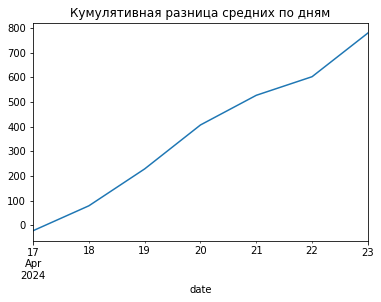

In [20]:
df_merged = pd.concat([df_control_capped,df_test_capped])
daily_stats = df_merged.groupby(['date', 'group'])['amount'].mean().unstack()
daily_stats['diff'] = daily_stats['treatment'] - daily_stats['control']
daily_stats['cumulative_diff'] = daily_stats['diff'].cumsum()
daily_stats['cumulative_diff'].plot(title='Кумулятивная разница средних по дням')

Вывод: значения тестовой группы почти всегда выше контрольной

## Применим стат тесты

### Welch's t-test 

оценим значимость и величину эффекта при уровне значимости = 0,05

In [21]:
t_stat, p_value=stats.ttest_ind(df_test_capped['amount'], df_control_capped['amount'], equal_var=False)

print(f'Т-статистика {t_stat} p_value = {p_value:.8f}')
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f" Вывод: Разница статистически значима")
else:
    print(f"Вывод: Разница НЕ статистически значима")


Т-статистика 4.81854594847702 p_value = 0.00000146
p-value: 0.000001
 Вывод: Разница статистически значима


рассчитаем меру коэна, чтобы оценть величину эффекта

In [22]:
std1=np.std(df_test_capped['amount'])
std2=np.std(df_control_capped['amount'])
mean_diff = np.mean(df_test_capped['amount'])-np.mean(df_control_capped['amount'])

pooled_std = np.sqrt((std1**2 + std2**2) / 2)
cohens_d = mean_diff / pooled_std
print(f"Cohen's d = {cohens_d:.3f}")  
if cohens_d < 0.2:
    print('Эффект незначительный')
else:
    print('Эффект значительный')

Cohen's d = 0.070
Эффект незначительный


### mannwhitneyu 

оценим значимость и величину эффекта при уровне значимости = 0,05

In [23]:
u_stat, p_value=stats.mannwhitneyu(df_test_capped['amount'], df_control_capped['amount'],alternative='two-sided') 
print(f'U-статистика {u_stat} p_value {p_value:.8f}')
if p_value < 0.05:
    print(f" Вывод: Разница статистически значима")
    prob_superiority = u_stat/(df_test_capped.shape[0] * df_control_capped.shape[0])
    if prob_superiority > 0.5:
        print (f' prob_superiority = {prob_superiority:.2%} значит, что вероятность того, что случайное значение из теста больше случайного из контроля')
else:
    print(f'Вывод: Разница НЕ статистически значима p_value = {p_value:.8f}')


U-статистика 47650131.0 p_value 0.00000515
 Вывод: Разница статистически значима
 prob_superiority = 51.90% значит, что вероятность того, что случайное значение из теста больше случайного из контроля


### бутстрап


оценим значимость при уровне значимости = 0,05 и рассчитаем доверительный интервал

In [24]:
def bootstrap_pvalue(data1, data2, n_bootstrap=10000):
    """p-value: перевыборка из ОБЪЕДИНЕННЫХ данных (нулевая гипотеза)"""
    n1, n2 = len(data1), len(data2)
    combined = np.concatenate([data1, data2])
    observed = np.mean(data1) - np.mean(data2)
    
    diffs_null = []
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(combined, size=n1, replace=True)
        sample2 = np.random.choice(combined, size=n2, replace=True)
        diffs_null.append(np.mean(sample1) - np.mean(sample2))
    
    diffs_null = np.array(diffs_null)
    p_value = np.mean(np.abs(diffs_null) >= np.abs(observed))
    return p_value, diffs_null

def bootstrap_ci(data1, data2, n_bootstrap=10000):
    """Доверительный интервал: перевыборка ВНУТРИ групп"""
    n1, n2 = len(data1), len(data2)
    observed = np.mean(data1) - np.mean(data2)
    
    diffs = []
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        diffs.append(np.mean(sample1) - np.mean(sample2))
    
    diffs = np.array(diffs)
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
    return ci_lower, ci_upper, diffs

# Использование
p_val, _ = bootstrap_pvalue(df_test_capped['amount'].to_list(), df_control_capped['amount'].to_list())
ci_low, ci_up, _ = bootstrap_ci(df_test_capped['amount'].to_list(), df_control_capped['amount'].to_list())

if p_val < 0.05:
    print(f'Вывод: Разница статистически значима')
    print(f'Доверительный интервал между {ci_low:.2f} и {ci_up:.2f}')
else:
    print(f"Вывод: Разница НЕ статистически значима")



Вывод: Разница статистически значима
Доверительный интервал между 66.81 и 155.67


# Вывод

Тестируемое изменение приводит к статистически значимому росту выручки.

- **Средняя выручка на пользователя в контрольной группе:** 3 461 руб.
- **Средняя выручка на пользователя в тестовой группе:** 3 573 руб.
- **Наблюдаемый рост:** **+112 руб. (+3.24%)**

Мы проверили результат тремя разными статистическими методами. Все они дали одинаковый ответ: **эффект есть, он не случайен**.<br>
Чтобы определить насколько эффект велик:
- был рассчитан показатель Cohen's d, значение которого 0,07 говорит о том что эффект небольшой, но стабильный
- доверительный интервал состави от +67 до +157 руб. дополнительной выручки или рост на +1.9% до +4.5%

Также была проведена проверка стабильности результата во времени, которая показала, что эффект надежен.

Мы провели **A/A-тест**: разбили контрольную группу на две случайные подгруппы и проверили, как часто статистические методы ошибочно находят разницу.

- **t-тест прошел проверку** — ему можно доверять.
- Mann-Whitney показал чуть больше ложных срабатываний, поэтому основной вывод мы делаем по t-тесту.


**Рекомендуется раскатить изменение на 100% пользователей.**

